## Face and Facial Keypoint detection

After you've trained a neural network to detect facial keypoints, you can then apply this network to *any* image that includes faces. The neural network expects a Tensor of a certain size as input and, so, to detect any face, you'll first have to do some pre-processing.

1. Detect all the faces in an image using a face detector (we'll be using a Haar Cascade detector in this notebook).
2. Pre-process those face images so that they are grayscale, and transformed to a Tensor of the input size that your net expects. This step will be similar to the `data_transform` you created and applied in Notebook 2, whose job was tp rescale, normalize, and turn any iimage into a Tensor to be accepted as input to your CNN.
3. Use your trained model to detect facial keypoints on the image.

---

In the next python cell we load in required libraries for this section of the project.

In [1]:
#234567890#234567890#234567890#234567890#234567890#234567890#234567890#234567890
import cv2
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import torch

from models import Net2

In [2]:
IMG = './images'

In [3]:
!ls images

download_ex.png        landmarks_numbered.jpg straw_hat.png
face_filter_ex.png     michelle_detected.png  sunglasses.png
feature_map_ex.png     mona_lisa.jpg          the_beatles.jpg
haar_cascade_ex.png    moustache.png
key_pts_example.png    obamas.jpg


#### Select an image


Select an image to perform facial keypoint detection on; you can select any image of faces in the `images/` directory.

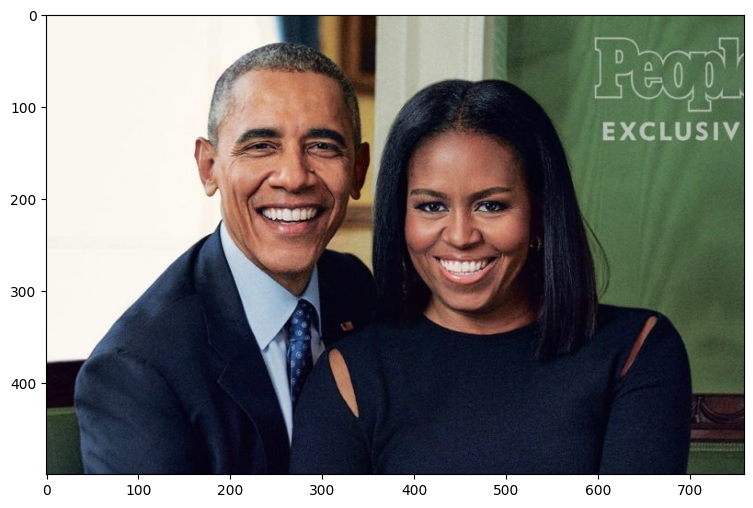

In [4]:
image = cv2.imread(f'{IMG}/obamas.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
fig = plt.figure(figsize=(9, 9))
plt.imshow(image);

## Detect all faces in an image

Next, you'll use one of OpenCV's pre-trained Haar Cascade classifiers, all of which can be found in the `detector_architectures/` directory, to find any faces in your selected image.

In the code below, we loop over each face in the original image and draw a red square on each face (in a copy of the original image, so as not to modify the original). You can even [add eye detections](https://docs.opencv.org/3.4.1/d7/d8b/tutorial_py_face_detection.html) as an *optional* exercise in using Haar detectors.

An example of face detection on a variety of images is shown below.

<img src='images/haar_cascade_ex.png' width=80% height=80%/>


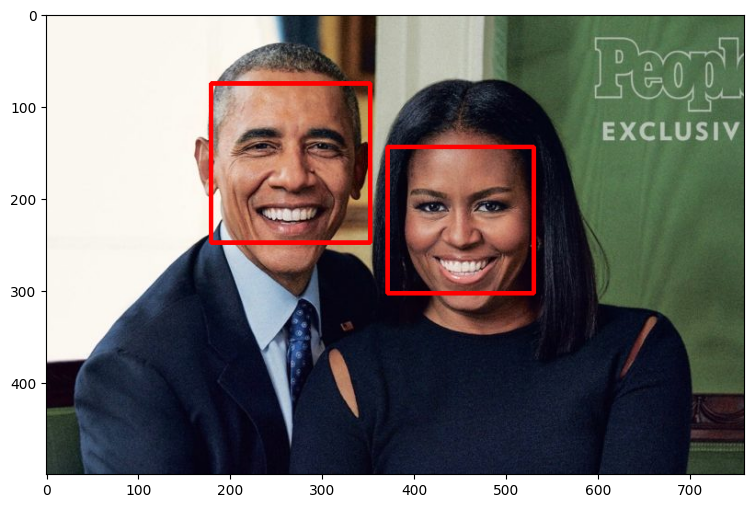

In [5]:
# load in a haar cascade classifier for detecting frontal faces
face_cascade = cv2.CascadeClassifier(
    'detector_architectures/haarcascade_frontalface_default.xml')
# the output here is an array of detections; the corners of each detection box
# if necessary, modify these parameters until you successfully identify every 
# face in a given image
faces = face_cascade.detectMultiScale(image, 1.2, 2)
image_with_detections = image.copy()
for (x, y, w, h) in faces:
    # draw a rectangle around each detected face
    # you may also need to change the width of the rectangle drawn depending
    # on image resolution
    cv2.rectangle(image_with_detections, (x, y), (x + w, y + h), (255, 0, 0), 3) 
fig = plt.figure(figsize=(9, 9))
plt.imshow(image_with_detections);

## Loading in a trained model

Once you have an image to work with (and, again, you can select any image of faces in the `images/` directory), the next step is to pre-process that image and feed it into your CNN facial keypoint detector.

First, load your best model by its filename.

In [6]:
net = Net2()

# TODO: load the best saved model parameters (by your path name)
# You'll need to un-comment the line below and add the correct name for *your*
# saved model
net.load_state_dict(torch.load('saved_models/keypoints_model_1.pt'))

## print out your net and prepare it for testing (uncomment the line below)
net.eval()

Net2(
  (stem): ConvBlock(
    (block): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (stage1): ResidBlock(
    (main): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (skip): Sequential(
      (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (relu): ReLU(inplace=True)
  )
  (stage2): ResidBlock(
    (main): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1)

## Keypoint detection

Now, we'll loop over each detected face in an image (again!) only this time, you'll transform those faces in Tensors that your CNN can accept as input images.

### TODO: Transform each detected face into an input Tensor

You'll need to perform the following steps for each detected face:
1. Convert the face from RGB to grayscale
2. Normalize the grayscale image so that its color range falls in [0,1] instead of [0,255]
3. Rescale the detected face to be the expected square size for your CNN (224x224, suggested)
4. Reshape the numpy image into a torch image.

**Hint**: The sizes of faces detected by a Haar detector and the faces your network has been trained on are of different sizes. If you find that your model is generating keypoints that are too small for a given face, try adding some padding to the detected `roi` before giving it as input to your model.

You may find it useful to consult to transformation code in `data_load.py` to help you perform these processing steps.


### TODO: Detect and display the predicted keypoints

After each face has been appropriately converted into an input Tensor for your network to see as input, you can apply your `net` to each face. The ouput should be the predicted the facial keypoints. These keypoints will need to be "un-normalized" for display, and you may find it helpful to write a helper function like `show_keypoints`. You should end up with an image like the following with facial keypoints that closely match the facial features on each individual face:

<img src='images/michelle_detected.png' width=30% height=30%/>




In [7]:
def show_keypoints(image, key_pts):
    'Show image with keypoints'
    plt.imshow(image, cmap='gray')
    plt.scatter(key_pts[:, 0], key_pts[:, 1], s=20, marker='.', c='m')

(1, 224, 224)


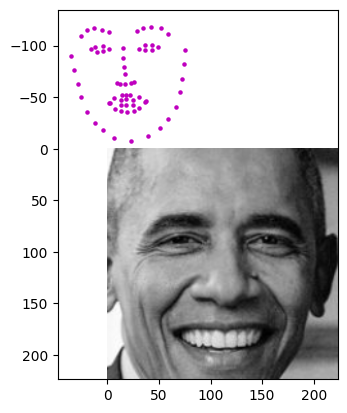

(1, 224, 224)


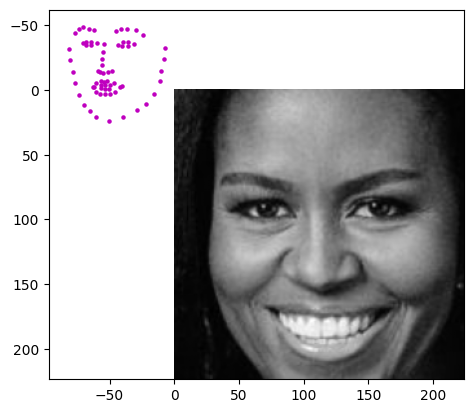

In [38]:
image_copy = np.copy(image)
# loop over the detected faces from your haar cascade
for (x, y, w, h) in faces:
    # Select the region of interest that is the face in the image 
    roi = image_copy[y:y + h, x:x + w]    
    #roi = image_copy[y - 10:y + h + 10, x - 10:x + w + 10]    
    # TODO: Convert the face region from RGB to grayscale
    roi = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
    # TODO: Normalize the grayscale image so that its color range falls in [0,1]
    # instead of [0, 255]
    roi = roi / 255.
    # TODO: Rescale the detected face to be the expected square size for your 
    # CNN (224x224, suggested)
    roi = cv2.resize(roi, (224, 224))
    roi = np.expand_dims(roi, axis=0)
    # TODO: Reshape the numpy image shape (H x W x C) into a torch image shape
    # (C x H x W)
    #roi = roi.transpose((2, 0, 1))
    print(roi.shape)
    # TODO: Make facial keypoint predictions using your loaded, trained network 
    roi = torch.from_numpy(roi).float()
    roi = roi.unsqueeze(0)
    keypoints = net(roi)
    keypoints = keypoints.view(keypoints.size()[0], 68, -1)
    #keypoints = cv2.resize(keypoints.squeeze(), (224, 224))
    keypoints = keypoints.detach().numpy()
    # TODO: Display each detected face and the corresponding keypoints        
    kp = keypoints.squeeze()
    show_keypoints(roi.squeeze(), 22 * kp)
    plt.show()

In [35]:
cv2.resize(kp, (224, 224))

array([[-3.7119524 , -3.7119524 , -3.7119524 , ..., -1.4363092 ,
        -1.4363092 , -1.4363092 ],
       [-3.7119524 , -3.7119524 , -3.7119524 , ..., -1.4363092 ,
        -1.4363092 , -1.4363092 ],
       [-3.7023895 , -3.7023895 , -3.7023895 , ..., -1.3334122 ,
        -1.3334122 , -1.3334122 ],
       ...,
       [-2.5526614 , -2.5526614 , -2.5526614 , ..., -0.05772438,
        -0.05772438, -0.05772438],
       [-2.5890594 , -2.5890594 , -2.5890594 , ..., -0.06093103,
        -0.06093103, -0.06093103],
       [-2.5890594 , -2.5890594 , -2.5890594 , ..., -0.06093103,
        -0.06093103, -0.06093103]], shape=(224, 224), dtype=float32)